## Quick Start

In [1]:
from sft_wick import Field, Vertex, Action, compute_moment, reset_uid_counter
from IPython.display import display, Math

# Define scalar fields
phi = Field('phi', 'physical')
psi = Field('psi', 'response')

# Compute <phi(x) phi(y)>_{S_0}  (pure C, no phase factor)
reset_uid_counter()
obs = [phi('x'), phi('y')]
result = compute_moment(obs, Action(vertices=[]), order=6)
display(Math(r"\langle \phi(x)\,\phi(y) \rangle_{S_0} = " + result.to_latex()))

# Compute <phi(x) psi(y)>_{S_0}  (response phase: -i R)
reset_uid_counter()
obs = [phi('x'), psi('y')]
result = compute_moment(obs, Action(vertices=[]), order=6, ito=False, response_phase=False)
display(Math(r"\langle \phi(x)\,\psi(y) \rangle_{S_0} = " + result.to_latex()))

# Same without response phase (raw R)
reset_uid_counter()
obs = [phi('x'), psi('y')]
result = compute_moment(obs, Action(vertices=[]), order=4, ito=False, response_phase=True)
display(Math(r"\text{Raw (no phase): } " + result.order(3).to_latex()))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Multi-Component Fields and Perturbative Expansion

In [2]:
from sft_wick import Field, Vertex

# Multi-component fields
phi = Field('phi', 'physical', n_components=3)
psi = Field('psi', 'response', n_components=3)

# Local vertex: ∫ F_{ijk} φ_i(x) φ_j(x) ψ_k(x) dx
v1 = Vertex(fields=[phi, phi, psi], coupling='F')

# Non-local vertex: ∬ K_{ijk}(x, x', x'') ψ_i(x) ψ_j(x') ψ_k(x'') dx dx' dx''
v2 = Vertex(fields=[psi, psi, psi], coupling='K_3', local=False)

In [3]:
from sft_wick import Action, compute_moment
from IPython.display import display, Math

reset_uid_counter()
action = Action(vertices=[v1])
obs = [phi('a', 'x')]

# Default: ito=True (Itô prescription + causal R-loop elimination)
#          response_phase=True (multiply by (-i)^n per R propagator)
result = compute_moment(obs, action, order=5, response_phase=True)

# Access individual orders
for n in range(6):
    latex = result.order(n).to_latex()
    display(Math(rf"O({n}) = {latex}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

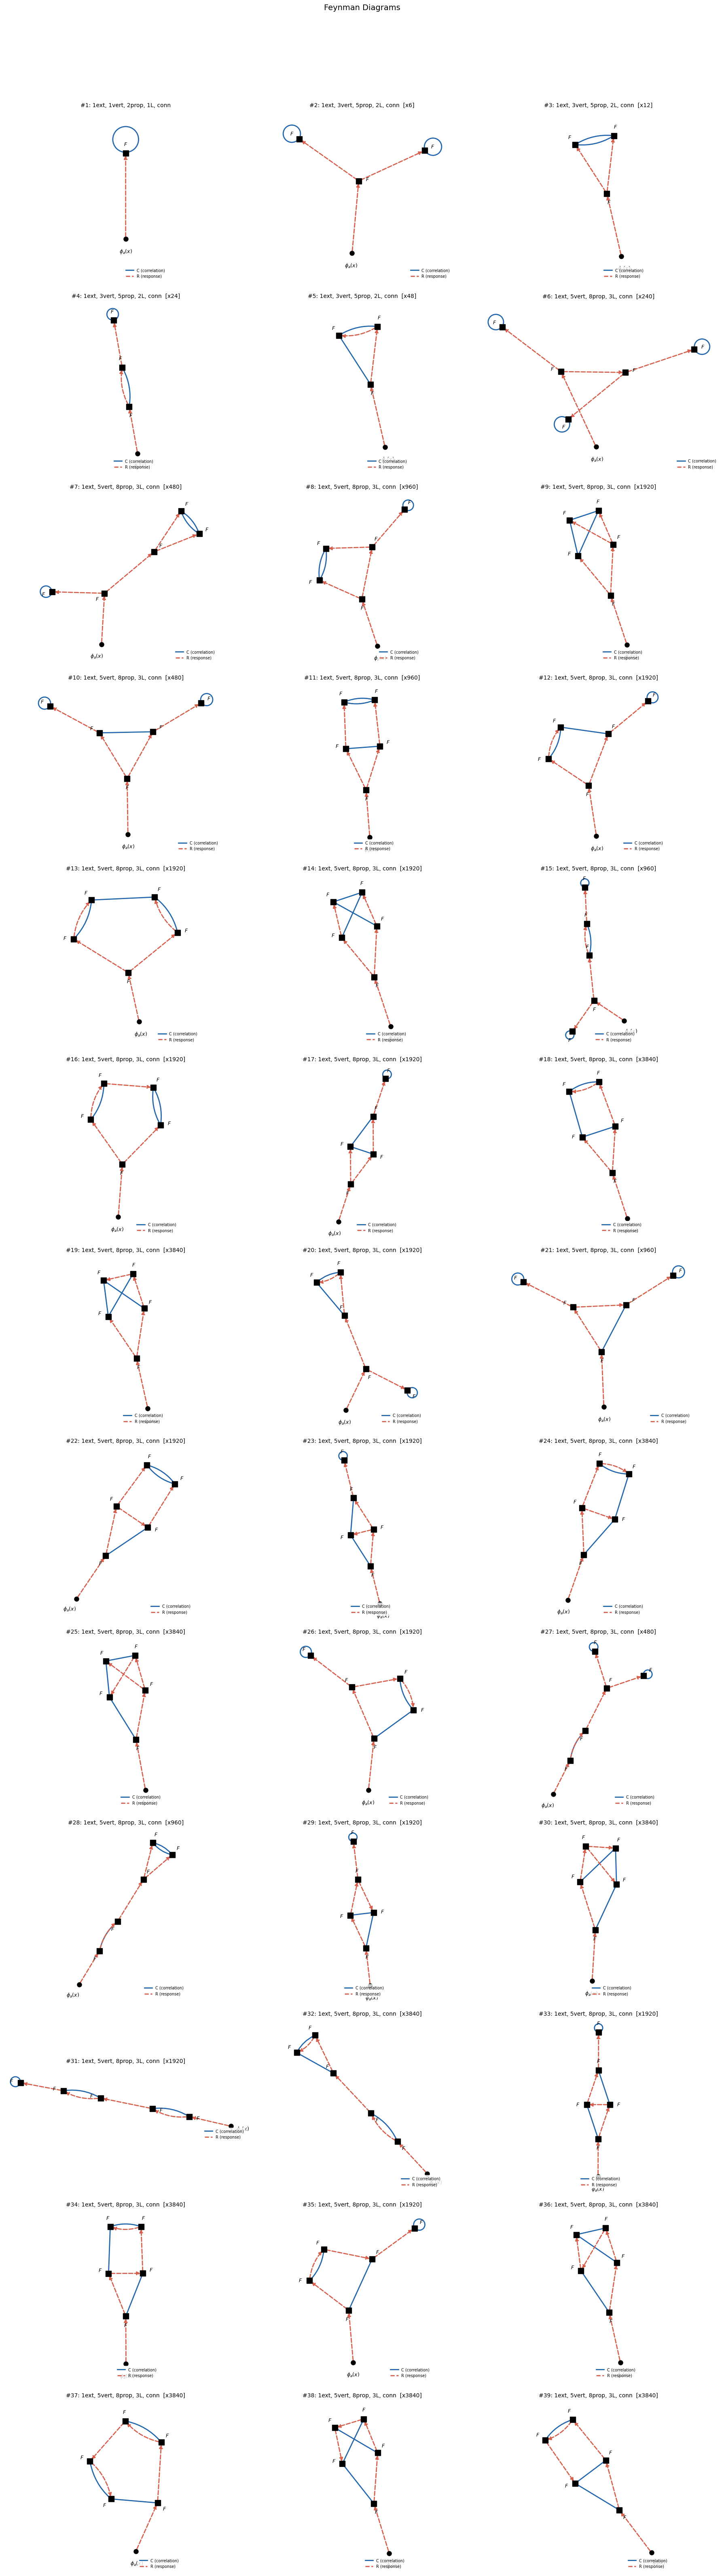

In [4]:
# Draw all diagrams
result.draw_diagrams()


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

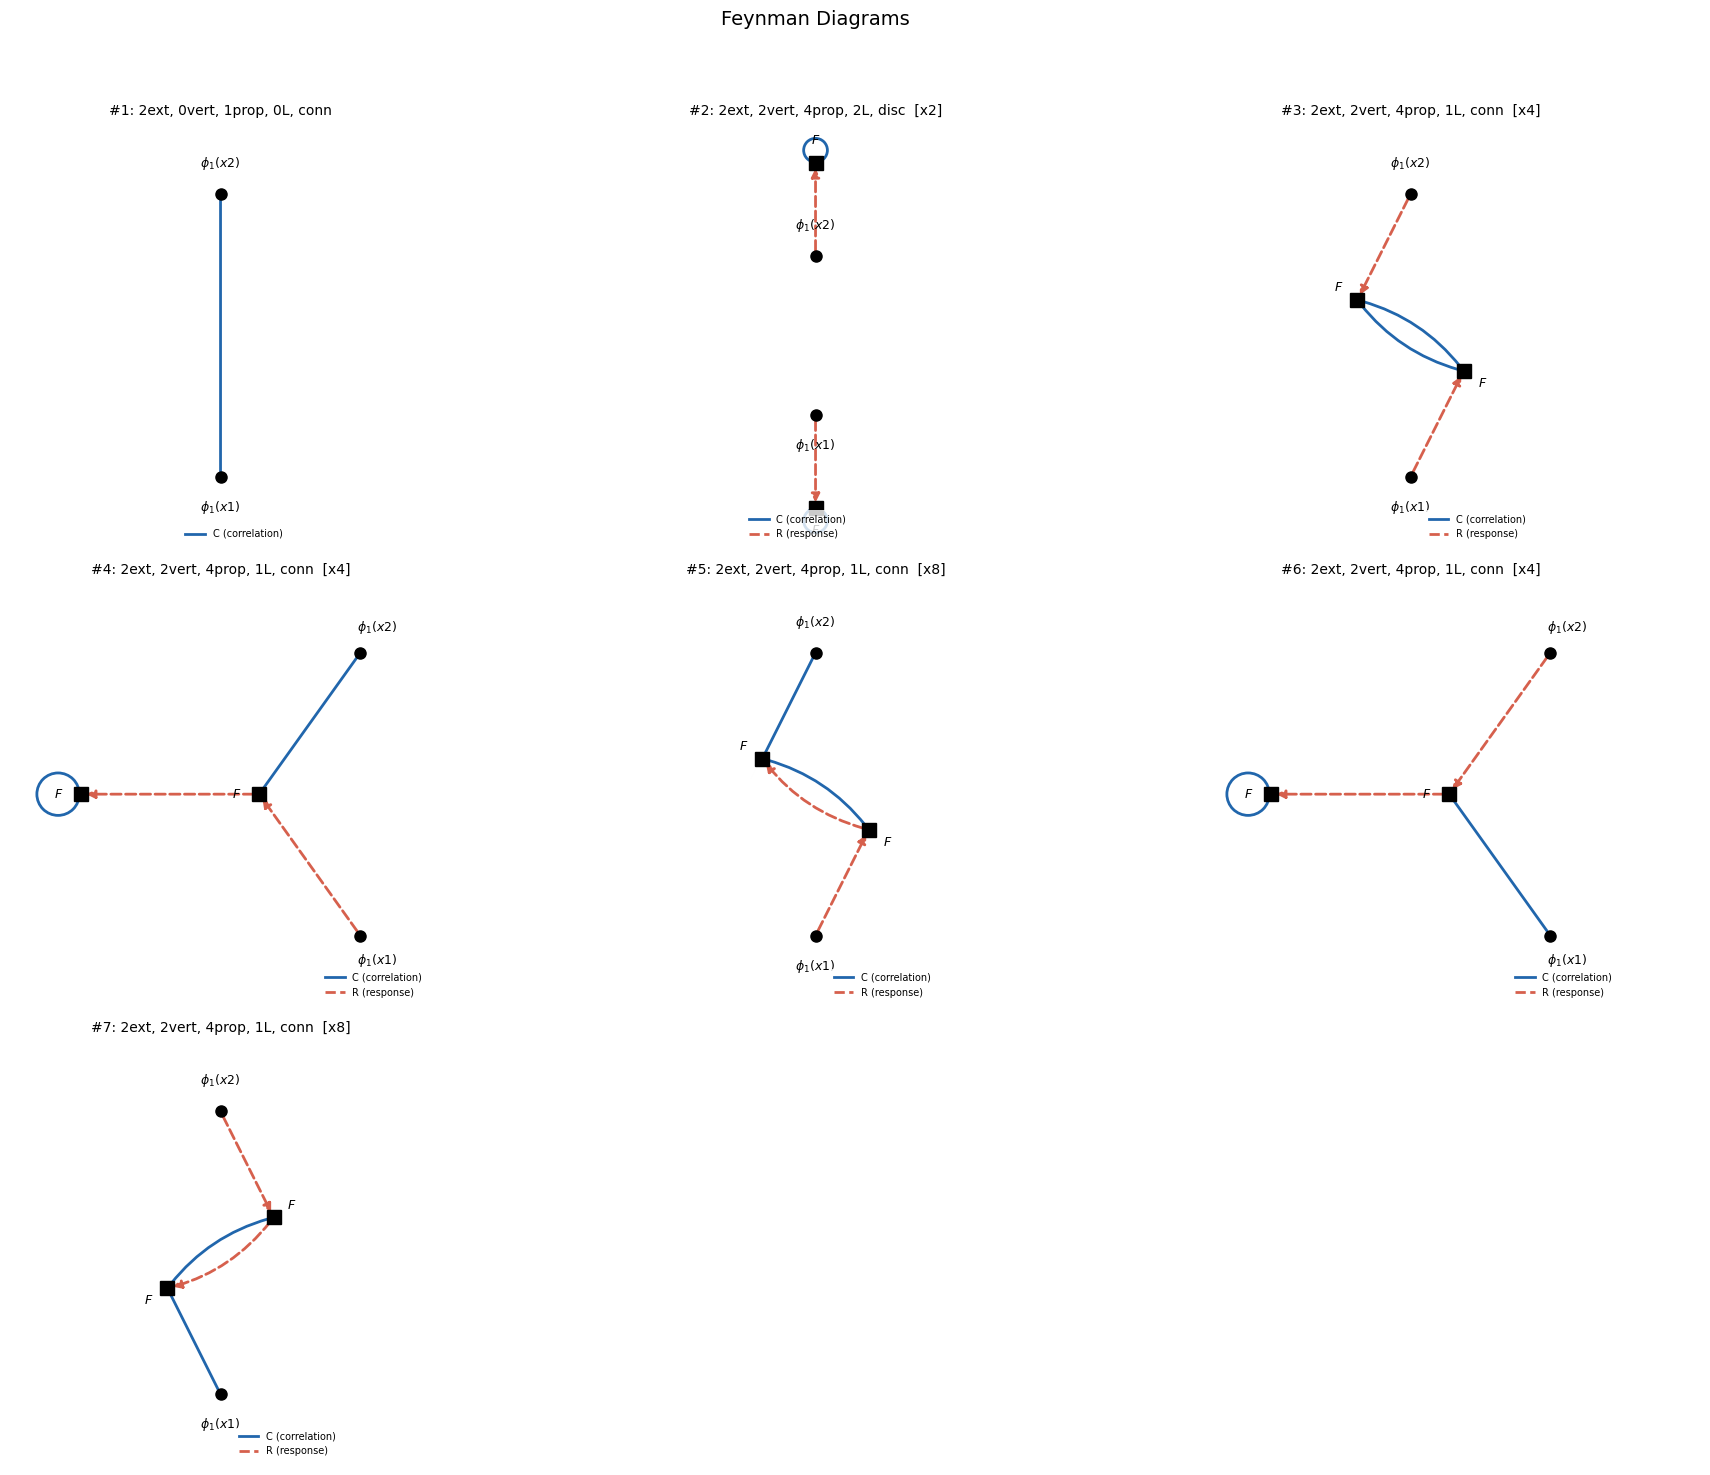

In [13]:
reset_uid_counter()
action = Action(vertices=[v1])
obs = [phi('1', 'x1'), phi('1', 'x2')]

# Default: ito=True (Itô prescription + causal R-loop elimination)
#          response_phase=True (multiply by (-i)^n per R propagator)
result = compute_moment(obs, action, order=3, response_phase=True)

# Access individual orders
for n in range(4):
    latex = result.order(n).to_latex()
    display(Math(rf"O({n}) = {latex}"))

# Draw only diagrams at a specific order
# result.draw_diagrams(order=2)
result.draw_diagrams()

# # Access diagram topology
# for d_info in result.diagrams_by_order[1]:
#     fd = d_info.to_feynman_diagram()
#     print(fd.summary())
#     print(f"  Loops: {fd.n_loops}, Connected: {fd.is_connected}")

In [14]:
from sft_wick import LaTeXFormatter
from IPython.display import display, Math

# Default names
display(Math(r"\text{Default: } " + result.order(0).to_latex()))

# Custom propagator names
fmt = LaTeXFormatter(propagator_names={
    'C': 'G',
    'R': r'R^{\mathrm{ret}}'
})
display(Math(r"\text{Custom: } " + fmt.format(result.order(0))))

# LaTeX align environment for order-by-order display
print("LaTeX align source:")
print(fmt.format_aligned(result.order_terms))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

LaTeX align source:
\begin{align}
  O(0) &= G_{11}(x1, x2) \\
  O(1) &= 0 \\
  O(2) &= \sum_{i_5=1}^{3} \sum_{i_4=1}^{3} \sum_{i_3=1}^{3} \sum_{i_2=1}^{3} \sum_{i_1=1}^{3} \sum_{i_0=1}^{3} \int \mathrm{d}y_1\, \int \mathrm{d}y_0\, -\frac{1}{2} \left(2 F_{i_0i_1i_2} F_{i_3i_4i_5} R^{\mathrm{ret}}_{1i_2}(x1, y_0) R^{\mathrm{ret}}_{1i_5}(x2, y_1) G_{i_0i_1}(y_0, y_0) G_{i_3i_4}(y_1, y_1) + \left(2 F_{i_0i_1i_2} F_{i_3i_4i_5} + F_{i_0i_1i_2} F_{i_4i_3i_5} + F_{i_3i_4i_5} F_{i_1i_0i_2}\right) R^{\mathrm{ret}}_{1i_2}(x1, y_0) R^{\mathrm{ret}}_{1i_5}(x2, y_1) G_{i_0i_3}(y_0, y_1) G_{i_1i_4}(y_0, y_1) + \left(2 F_{i_0i_1i_2} F_{i_3i_4i_5} + 2 F_{i_1i_0i_2} F_{i_3i_4i_5}\right) R^{\mathrm{ret}}_{1i_2}(x1, y_0) R^{\mathrm{ret}}_{i_0i_5}(y_0, y_1) G_{1i_1}(x2, y_0) G_{i_3i_4}(y_1, y_1) + \left(2 F_{i_0i_1i_2} F_{i_3i_4i_5} + 2 F_{i_0i_1i_2} F_{i_4i_3i_5} + 2 F_{i_1i_0i_2} F_{i_3i_4i_5} + 2 F_{i_1i_0i_2} F_{i_4i_3i_5}\right) R^{\mathrm{ret}}_{1i_2}(x1, y_0) R^{\mathrm{ret}}_{i_0i_5}(y_0, y_1) G_{1

## Itô Prescription and Causal R-Loop Elimination

By default (`ito=True`), two physics-motivated simplifications are applied:

1. **Equal-point R vanishes**: $R(x,x) = 0$ — the Itô convention $\Theta(0) = 0$.
2. **Causal R-loops vanish**: Any cycle $R(a,b)\,R(b,c)\cdots R(z,a) = 0$ — cyclic time ordering is impossible for the retarded propagator.

In [15]:
from IPython.display import display, Math

reset_uid_counter()
phi = Field('phi', 'physical')
psi = Field('psi', 'response')

# <psi(x) phi(x) phi(x) phi(x)>_{S_0}
# All operators at the same point x, so every R(x,x) appears.
obs = [psi('x'), phi('x'), phi('x'), phi('x')]

# With Ito (default): R(x,x) = 0, so entire result vanishes
result_ito = compute_moment(obs, Action(vertices=[]), order=0)
display(Math(r"\text{With Itô: } \langle \psi(x)\,\phi^3(x) \rangle_{S_0} = " + result_ito.order(0).to_latex()))

# Without Ito: R(x,x) is kept symbolic
result_no_ito = compute_moment(obs, Action(vertices=[]), order=0, ito=False, response_phase=False)
display(Math(r"\text{Without Itô: } \langle \psi(x)\,\phi^3(x) \rangle_{S_0} = " + result_no_ito.order(0).to_latex()))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [16]:
# Causal R-loop elimination example:
# At first order, some pairings produce R(x,z)R(z,x) which vanishes.
reset_uid_counter()
v = Vertex(fields=[phi, psi], coupling='g')
action = Action(vertices=[v])
obs = [phi('x'), phi('y')]

result_ito = compute_moment(obs, action, order=1, response_phase=False)
result_no_ito = compute_moment(obs, action, order=1, ito=False, response_phase=False)

print(f"Diagrams with Itô:    {len(result_ito.diagrams_by_order.get(1, []))}")
print(f"Diagrams without Itô: {len(result_no_ito.diagrams_by_order.get(1, []))}")

display(Math(r"\text{With Itô: } " + result_ito.order(1).to_latex()))
display(Math(r"\text{Without Itô: } " + result_no_ito.order(1).to_latex()))

Diagrams with Itô:    2
Diagrams without Itô: 3


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Response Phase Convention

The MSR convention $\langle\phi(a)\,\psi(b)\rangle = -\mathrm{i}\,R(a,b)$ is implemented by multiplying each term by $(-\mathrm{i})^n$ where $n$ is the number of response propagators $R$ in that term. This is controlled by `response_phase=True` (default).

In [17]:
from sft_wick import apply_response_phase
from IPython.display import display, Math

reset_uid_counter()
phi = Field('phi', 'physical')
psi = Field('psi', 'response')
v = Vertex(fields=[phi, psi], coupling='g')
action = Action(vertices=[v])
obs = [phi('x'), phi('y')]

# With response phase (default): R propagators carry (-i) factor
result_phase = compute_moment(obs, action, order=1)
display(Math(r"\text{With phase: } " + result_phase.order(1).to_latex()))

# Without response phase: raw R propagators
result_raw = compute_moment(obs, action, order=1, response_phase=False)
display(Math(r"\text{Without phase: } " + result_raw.order(1).to_latex()))

# You can also apply the phase manually:
manual = apply_response_phase(result_raw.order(1))
display(Math(r"\text{Manual phase: } " + manual.to_latex()))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Topology-Based Term Collection

By default (`collect_topology=True`), terms with the same propagator spatial structure are grouped. Propagators are factored out with canonical component indices, and coupling coefficients are summed with permuted indices. This dramatically reduces the number of terms at higher orders.

In [18]:
from IPython.display import display, Math

reset_uid_counter()
phi = Field('phi', 'physical', n_components=3)
psi = Field('psi', 'response', n_components=3)
v = Vertex(fields=[phi, phi, psi], coupling='F')
obs = [phi('a', 'x'), phi('b', 'y')]

# Without topology collection: many expanded terms
reset_uid_counter()
r_expanded = compute_moment(obs, Action([v]), order=2,
                            response_phase=False, collect_topology=False)

# With topology collection (default): grouped terms
reset_uid_counter()
r_collected = compute_moment(obs, Action([v]), order=2,
                             response_phase=False, collect_topology=True)

# Count inner Sum terms
def count_inner_terms(expr):
    from sft_wick.expressions import SumOverIndex, IntegralOver, Product, Sum
    inner = expr
    while isinstance(inner, (SumOverIndex, IntegralOver)):
        inner = inner.body
    if isinstance(inner, Product):
        for f in inner.factors:
            if isinstance(f, Sum):
                return len(f.terms)
    return 1

n_exp = count_inner_terms(r_expanded.order(2))
n_col = count_inner_terms(r_collected.order(2))
print(f"Expanded: {n_exp} terms  →  Collected: {n_col} terms")

# Show a few collected terms
display(Math(r"O(2) = " + r_collected.order(2).to_latex()[:300] + r"\cdots"))

Expanded: 30 terms  →  Collected: 6 terms


<IPython.core.display.Math object>